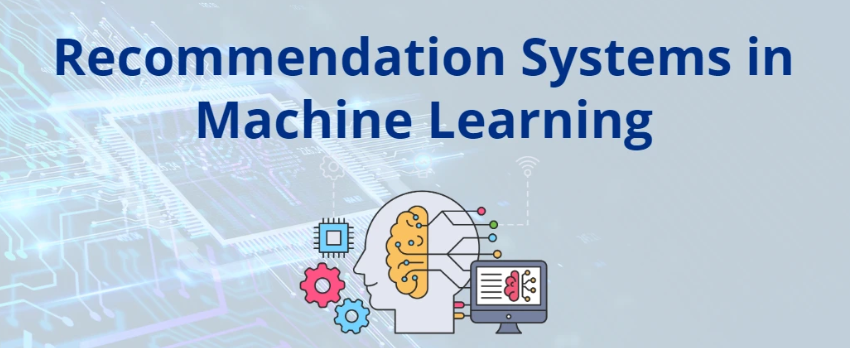

In [ ]:
# Netflix shows movie/web series to users. But Netflix cannot show everything to everyone

**Netflix wants to recommend movie/shows you will like before you search them - (means based on the user interest)**

**WHAT ARE RECOMMENDER SYSTEMS?**

Recommender systems are algorithm designed to suggest relevant items to the users. These systems are used in various domains such as e-commerce , streaming services and social media. They enhance user experience by filtering vast amount of information to deliver personalized content

#**SVD (Singular Value Decomposition)**

SVD works in a recommendation system by finding patterns in user preference and item similarities.

**Break a big problem/complex matrix into smaller meaningful parts**

**Ques - What SVD Does:**

- SVD looks at the ratings that are available and tries to figure out the hidden connection between user and items. It learns what kind of movies users like based on their previous rating.

In [ ]:
# SVD break the data into 3 important parts -
# User Behaviour
# Strength
# Movie Type

**User behaviour** - What kind of movies users like

**Strength** - How strong that liking is

**Movie Type**- What kind of movies they are

In [ ]:
# FORMULA FOR SVD IS -

A=UΣV^T

In [ ]:
# A -> Original Matrix
# Example -> User - Movie Ratings

In [ ]:
# U (User behaviour/user matrix)
# information about users -> What type of movies they like

In [ ]:
# Sigma
# Importance of each hidden feature
# Big number = very important
# small number = less important

In [ ]:
# third component -> (movie matrix)
# information about movies
# What type of movie each one is -
# M1 - action - heavy
# M2 - comedy-heavy
# M3 - thriller - heavy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Because data is very large so we will connect colab with our drive
# Drive mount
from google.colab import drive

In [ ]:
drive.mount("/content/drive") # colab connected to google drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Read the first data ( Text file)
netflix_dataset=pd.read_csv("/content/drive/MyDrive/Netflix/combined_data_1.txt.zip",header=None , names=["Cust_Id" , "Rating"] , usecols=[0,1])

In [ ]:
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [ ]:
# check for null value / missing value
netflix_dataset.isnull().sum()
# For movie id's we don't have any ratings

,0
Cust_Id,0
Rating,4499


In [ ]:
# UNDERSTAND THE DATA-
# how many movies ?
# how many customers?
# how many ratings there?

In [ ]:
# Get the count of movies with the help of Cust_Id and Rating columns
movie_count = netflix_dataset.isnull().sum()['Rating']
# Number of NaN values in Rating = Number of movies
movie_count

4499

In [ ]:
# to calculate how many unique users/customers are there
total_count = netflix_dataset['Cust_Id'].nunique()
total_count

475257

In [ ]:
# but we know that in Cust_Id -> movie_id + customer_id
# So , let's find out the customer id
customer_count = total_count - movie_count
customer_count  # 4 lakh 70 thousand 7 hundred 58

470758

In [ ]:
# To calculate how many ratings do we have that are given by the users
rating_count = netflix_dataset['Cust_Id'].count() - movie_count
rating_count

24053764

In [ ]:
# NOW LET'S UNDERSTAND THE RATING DISTRIBUTION
# To find out how many users have rated  the movie as  1 , 2 ,3 ,4 ,5 stars
stars = netflix_dataset.groupby("Rating")['Rating'].count()
stars

,Rating
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


In [ ]:
# This counts how many 1-star, 2- star , 3-star , 4-star , 5-star exists

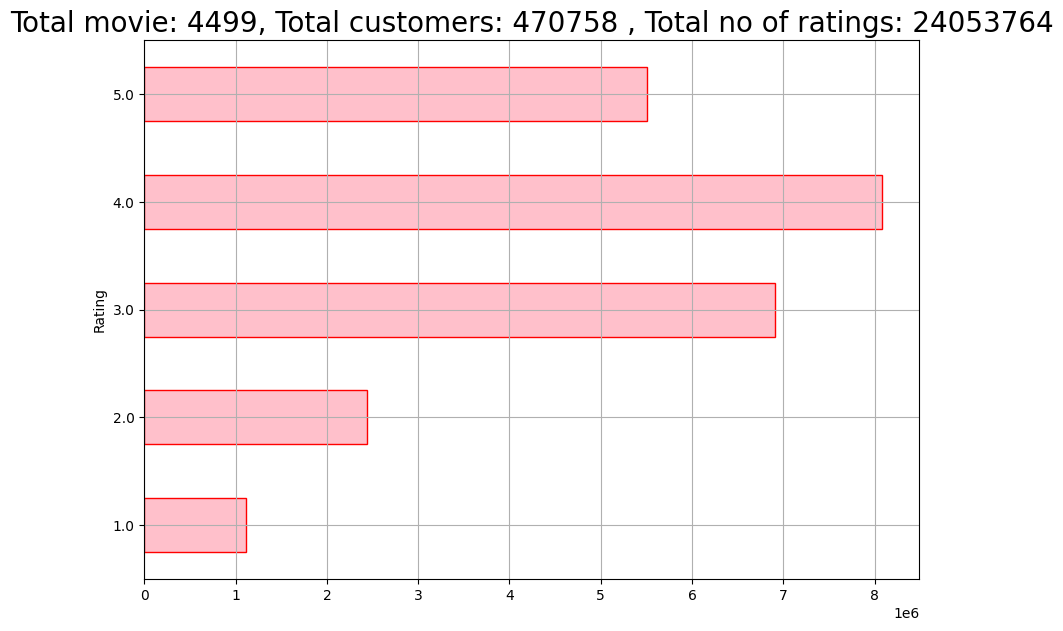

In [ ]:
ax = stars.plot(kind='barh',legend=False,figsize=(10,7),color='pink',edgecolor='red')
plt.title(f'Total movie: {movie_count}, Total customers: {customer_count} , Total no of ratings: {rating_count}' ,fontsize=20)
plt.grid(True)
plt.show()

In [ ]:
# CREATE A SEPARATE MOVIE ID COLUMN
# Because SVD can't work on messy real-world data/id's  - so we need clean , compact and proper data

In [ ]:
movie_id = None # the movie which we are currently reading
movie_np = [] # list where we will save the movie id for each row

for i in netflix_dataset['Cust_Id']:
  if ":" in i:
    movie_id = int(i.replace(":"," ")) # extract movie number


  # assign the current movie id to list
  movie_np.append(movie_id)

In [ ]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
# create a new column-
netflix_dataset['Movie_Id'] = movie_np

In [ ]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
# CLEANING THE DATA -
netflix_dataset = netflix_dataset[netflix_dataset['Rating'].notna()]
# to keep only the rows where the rating column is not having null values

In [ ]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [ ]:
# checking the info of data-
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [ ]:
# convert data type of cust_id column from object to int
# 8 :46 a.m
netflix_dataset['Cust_Id'] = netflix_dataset['Cust_Id'].astype(int)

/tmp/ipython-input-1349/4269467311.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset['Cust_Id'] = netflix_dataset['Cust_Id'].astype(int)


In [ ]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [ ]:
# PRE - FILTERTING:-
# Remove users and movies that provide little or unreliable information before training the model

**we will remove users with very few ratings** -> because they confuse the model

**movies with very few ratings**- because it is statiscally meaningless

In [ ]:
#  count the rating of movie_id-
dataset_movie_summary = netflix_dataset.groupby('Movie_Id')['Rating'].agg(['count'])
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [ ]:
# Now we will create a benchmark (consider a benchmark value like 60 percentile)
# If we keep too low -> many movies with the 1 - 5 ratings -> noisy model
# if we keep too high -> remove too many movies -> less data for training

In [ ]:
movie_benchmark = round(dataset_movie_summary['count'].quantile(0.6),0) # round off to how many decimal places
movie_benchmark

908.0

In [ ]:
# This means 60 % of movies have less than 908 ratings. And 40 % of movies have 908 or more ratings

In [ ]:
# drop the movies with rating less than benchmark value
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list # list that will store the index of all movies which are having ratings less than 908

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [ ]:
# A movie must have at least 908 ratings to stay in the dataset

In [ ]:
# How many movie we are going to remove
len(drop_movie_list)

2699

In [ ]:
# Remove all the users that are in-active ( who have rated less number of movies)
dataset_cust_summary = netflix_dataset.groupby('Cust_Id')['Rating'].agg(['count'])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [ ]:
# let's set a benchmark for remove customers who have given less ratings
cust_benchmark = round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [ ]:
# If any user have rated less than 36 movies please remove them
drop_cust_list = dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [ ]:
len(drop_cust_list)  # how many users we are going to remove

282042

In [ ]:
# here we have created :
# drop_movie_list -> movies to be removed
# drop_cust_id -> users to be removed
# But until now , dataset is still unchanged

In [ ]:
# NOW WE WILL REMOVE THIS DATA FROM OUR DATASET
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset = netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
# Consider only the movies and cust id which are not present in drop_movie_list and drop_cust_list

In [ ]:
netflix_dataset # Final shape of dataset after remove extra users and extra movie id

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [ ]:
# Final data which is left behind is having 1 crore 96 lakh 95 thousand 8 hundred thirty six rows

#**MODEL BUILDING**

In [ ]:
# Our combined dataset  contains only Cust_Id , Rating , Movie_Id
# But this dataset does not contain any movie name

In [ ]:
# Load the second dataset for movie names as with previous dataset we are having only movie_id
df_title = pd.read_csv("/content/drive/MyDrive/Netflix/movies (1) (1).csv",encoding='ISO-8859-1',usecols=[0,1,2])
df_title

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [ ]:
# rename the movie id column name here
df_title.rename(columns={'movieId':'Movie_Id'},inplace=True)

In [ ]:
df_title

,Movie_Id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


**Scikit - surprise** is a library built specifically for recommender systems. It handles:

- matrix creation

- it will learn from user , then predict and evaluate

In [ ]:
 pip install numpy==1.26.4

In [ ]:
# If your scikit library shows an error while installing then uncomment numpy part and restart the session
# Scikit shows error because of version of numpy

In [ ]:
!pip install scikit-surprise

In [ ]:
from surprise import Reader , Dataset , SVD
from surprise.model_selection import cross_validate

In [ ]:
# Reader -> it act as a translater
# our data is in pandas, so reader act like a translator

In [ ]:
# Dataset -> the converter
# convert your pandas data into surprise internal structure (matrix)

In [ ]:
# SVD -> brain of the system model

In [ ]:
reader = Reader()

In [ ]:
# we only work with top 100k records for quick runtime
# Dataset.load_from_df -> convert pandas DataFrame -> surprise dataset
data = Dataset.load_from_df(netflix_dataset[['Cust_Id' , 'Movie_Id' , 'Rating']][:100000],reader)

In [ ]:
# The Netflix dataset is huge.
# We are taking 100k rows to make training fast for demonstration

In [ ]:
data

In [ ]:
# Train the recommendation model-
model = SVD()

In [ ]:
cross_validate(model,data,measures=['RMSE'],cv=3)

{'test_rmse': array([1.02031842, 1.01796724, 1.01717082]),
 'fit_time': (3.0732741355895996, 3.2014222145080566, 3.0810368061065674),
 'test_time': (0.6299474239349365, 0.4067418575286865, 0.18163442611694336)}

In [ ]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


#**Recommendation**

In [ ]:
# choose a user to recommend for
# We have randomly choose here one active customer id - 1331154
user_rating = netflix_dataset[netflix_dataset['Cust_Id']==1331154]
user_rating

,Cust_Id,Rating,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [ ]:
# user 1331154 has rated 253 movies

In [ ]:
# Make a copy of each individual customer for recommendation
user_1331154 = df_title.copy()
user_1331154

,Movie_Id,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [ ]:
# Remove the less rate movies from 2nd dataset also
user_1331154 = user_1331154[~user_1331154['Movie_Id'].isin(drop_movie_list)]

In [ ]:
user_1331154

,Movie_Id,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
7,8,Tom and Huck (1995),Adventure|Children
15,16,Casino (1995),Crime|Drama
...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy
27275,131258,The Pirates (2014),Adventure
27276,131260,Rentun Ruusu (2001),(no genres listed)


In [ ]:
# prediction part
user_1331154['Estimated_Score'] = user_1331154['Movie_Id'].apply(lambda x:model.predict(1331154,x).est)

/tmp/ipython-input-1349/2406022153.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154['Estimated_Score'] = user_1331154['Movie_Id'].apply(lambda x:model.predict(1331154,x).est)


In [ ]:
user_1331154

,Movie_Id,title,genres,Estimated_Score
2,3,Grumpier Old Men (1995),Comedy|Romance,3.440851
4,5,Father of the Bride Part II (1995),Comedy,3.433931
5,6,Heat (1995),Action|Crime|Thriller,3.056959
7,8,Tom and Huck (1995),Adventure|Children,3.888591
15,16,Casino (1995),Crime|Drama,2.561758
...,...,...,...,...
27273,131254,Kein Bund fÃ¼r's Leben (2007),Comedy,3.604891
27274,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,3.604891
27275,131258,The Pirates (2014),Adventure,3.604891
27276,131260,Rentun Ruusu (2001),(no genres listed),3.604891


In [ ]:
# display top 5 movies  with highest estmators
user_1331154.sort_values("Estimated_Score",ascending=False,inplace=True)

/tmp/ipython-input-1349/2233196137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154.sort_values("Estimated_Score",ascending=False,inplace=True)


In [ ]:
user_1331154.head(5)

,Movie_Id,title,genres,Estimated_Score
7,8,Tom and Huck (1995),Adventure|Children,3.888591
27,28,Persuasion (1995),Drama|Romance,3.842707
29,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,3.835835
24,25,Leaving Las Vegas (1995),Drama|Romance,3.689605
23,24,Powder (1995),Drama|Sci-Fi,3.688484
